In [239]:
import os, sys
import pandas as pd

RESULTS_PATH = '../results/paraphrase_balanced/'
col_names = ['task', 'lang', 'lang_setting', 'eval_type', 'data_setting', 'learning_rate', 'batch_size', 'epoch', 'seed', 'f1-micro', 'f1-macro', 'accuracy']
runs = []

# Paraphrase Generation
folder_names = [folder for folder in os.listdir(os.path.join(RESULTS_PATH)) if os.path.isdir(os.path.join(RESULTS_PATH, folder)) and folder != '.ipynb_checkpoints']

for folder_name in folder_names:
    try:
        df = pd.read_csv(os.path.join(RESULTS_PATH, folder_name, 'metrics_phrases.tsv'), sep = '\t')
        df = df.set_index(df.columns[0])
        
        cond_parameters = folder_name.split('_')

        if cond_parameters[3] == 'eval':
            cond_parameters[3] = cond_parameters[3] + '_' + cond_parameters[4]
            cond_parameters.pop(4)
        
        cond_parameters.append(df.loc['Micro-AVG', 'f1'])
        cond_parameters.append(df.loc['Macro-AVG', 'f1'])
        cond_parameters.append(df.loc['Micro-AVG', 'accuracy'])
        runs.append(cond_parameters)
    except:
        pass

# MVP

RESULTS_PATH = '../results/bert_clf_cased/'
folder_names = [folder for folder in os.listdir(os.path.join(RESULTS_PATH)) if os.path.isdir(os.path.join(RESULTS_PATH, folder)) and folder != '.ipynb_checkpoints']

for folder_name in folder_names:
    try:
        cond_parameters = folder_name.split('_')
        if cond_parameters[0] == 'acd':
            df = pd.read_csv(os.path.join(RESULTS_PATH, folder_name, 'metrics_asp.tsv'), sep = '\t')
        else:
            df = pd.read_csv(os.path.join(RESULTS_PATH, folder_name, 'metrics_asp_pol.tsv'), sep = '\t')
            
        df = df.set_index(df.columns[0])
        
        cond_parameters = folder_name.split('_')
        # Fix for the wrong output name format
        # cond_parameters[0], cond_parameters[1] = cond_parameters[1], cond_parameters[0]
        cond_parameters.append(df.loc['Micro-AVG', 'f1'])
        cond_parameters.append(df.loc['Macro-AVG', 'f1'])
        cond_parameters.append(df.loc['Micro-AVG', 'accuracy'])
        runs.append(cond_parameters)
    except:
        pass

results_all = pd.DataFrame(runs, columns = col_names)
results_all["f1-micro"] = pd.to_numeric(results_all["f1-micro"], errors="coerce")

In [240]:
import numpy as np
task = 'tasd'
data_setting = 'balanced'
lang_setting = 'adapted'

results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting])].groupby("lang")["f1-micro"].idxmax()] 
# [results_all['task'] == 'acsa'].sort_values(by='f1-micro', ascending=False)

,task,lang,lang_setting,eval_type,data_setting,learning_rate,batch_size,epoch,seed,f1-micro,f1-macro,accuracy
23,tasd,cs,adapted,eval-1,balanced,0.0003,16,30,5,0.5188,0.3231,0.3502
8,tasd,de,adapted,eval-1,balanced,0.0003,16,35,5,0.5414,0.4579,0.3712
28,tasd,en,adapted,eval-1,balanced,0.0003,16,40,5,0.5509,0.4940,0.3802
18,tasd,es,adapted,eval-1,balanced,0.0003,16,35,5,0.4846,0.3234,0.3198
24,tasd,fr,adapted,eval-1,balanced,0.0003,16,35,5,0.4519,0.4719,0.2919
15,tasd,nl,adapted,eval-1,balanced,0.0003,16,30,5,0.4157,0.2817,0.2624
34,tasd,ru,adapted,eval-1,balanced,0.0003,16,35,5,0.5271,0.4227,0.3578


In [241]:
import numpy as np
task = 'acsa'
data_setting = 'balanced'
lang_setting = 'orig'

results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting])].groupby("lang")["f1-micro"].idxmax()] 
# [results_all['task'] == 'acsa'].sort_values(by='f1-micro', ascending=False)

,task,lang,lang_setting,eval_type,data_setting,learning_rate,batch_size,epoch,seed,f1-micro,f1-macro,accuracy
335,acsa,cs,orig,eval-1,balanced,5e-05,16,45,5,0.6652,0.3452,0.4984
312,acsa,de,orig,eval-2,balanced,5e-05,16,40,5,0.6492,0.3121,0.4806
127,acsa,en,orig,eval-2,balanced,5e-05,16,50,5,0.6476,0.4721,0.4788
96,acsa,es,orig,eval-1,balanced,5e-05,16,35,5,0.6325,0.3210,0.4626
210,acsa,fr,orig,eval-1,balanced,5e-05,16,50,5,0.5683,0.3384,0.3970
180,acsa,nl,orig,eval-1,balanced,5e-05,16,45,5,0.5620,0.3226,0.3909
109,acsa,ru,orig,eval-1,balanced,5e-05,16,35,5,0.6052,0.2775,0.4339


In [164]:
RESULTS_PATH = '../results/ilo/'
col_names = ['task', 'lang', 'lang_setting', 'eval_type', 'data_setting', 'learning_rate', 'batch_size', 'epoch', 'seed', 'f1-micro', 'f1-macro', 'accuracy']
runs = []

# Paraphrase Generation
folder_names = [folder for folder in os.listdir(os.path.join(RESULTS_PATH)) if os.path.isdir(os.path.join(RESULTS_PATH, folder)) and folder != '.ipynb_checkpoints']

for folder_name in folder_names:
    try:
        df = pd.read_csv(os.path.join(RESULTS_PATH, folder_name, 'metrics_phrases.tsv'), sep = '\t')
        df = df.set_index(df.columns[0])
        
        cond_parameters = folder_name.split('_')
        # Fix for the wrong output name format
        # cond_parameters[0], cond_parameters[1] = cond_parameters[1], cond_parameters[0]
        cond_parameters.append(df.loc['Micro-AVG', 'f1'])
        cond_parameters.append(df.loc['Macro-AVG', 'f1'])
        cond_parameters.append(df.loc['Micro-AVG', 'accuracy'])
        runs.append(cond_parameters)
    except:
        pass

results_all = pd.DataFrame(runs, columns = col_names)
results_all["f1-micro"] = pd.to_numeric(results_all["f1-micro"], errors="coerce")

In [165]:
import numpy as np
task = 'tasd'
data_setting = 'orig'
lang_setting = 'orig'

results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting])].groupby("lang")["f1-micro"].idxmax()] 

,task,lang,lang_setting,eval_type,data_setting,learning_rate,batch_size,epoch,seed,f1-micro,f1-macro,accuracy
24,tasd,en,orig,test,orig,0.0003,8,30,5,0.4821,0.4349,0.3176


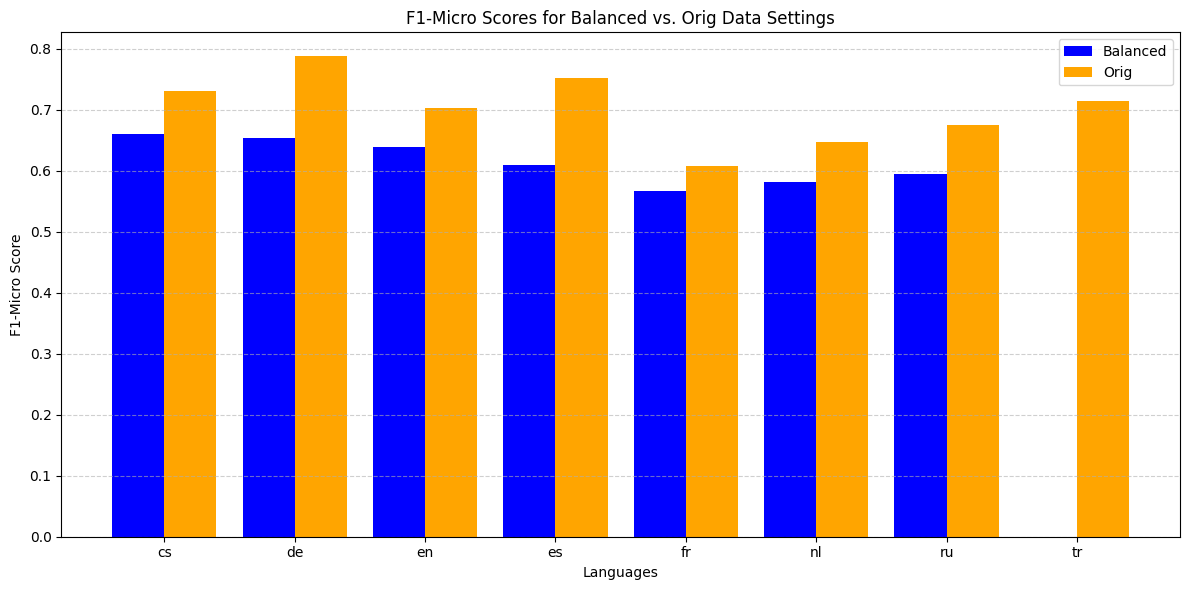

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

task = 'acsa'
data_setting = 'orig'
lang_setting = 'adapted'
lr = '2e-05'

df_balanced = results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting,
                                   # results_all['learning_rate'] == lr
                                  ])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting,
                                            # results_all['learning_rate'] == lr
])].groupby("lang")["f1-micro"].idxmax()] 


task = 'acsa'
data_setting = 'balanced'
lang_setting = 'orig'
lr = '2e-05'

df_orig = results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting,
                                   # results_all['learning_rate'] == lr
                                  ])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting,
                                            # results_all['learning_rate'] == lr
])].groupby("lang")["f1-micro"].idxmax()]  

# Merge the two dataframes on 'lang' (assuming language is the identifier)
df = pd.concat([df_balanced, df_orig])

# Filter to keep only 'balanced' and 'orig' settings
df = df[df["data_setting"].isin(["balanced", "orig"])]

# Extract languages and metrics (assuming 'f1-micro' is the metric you want to plot)
languages = df["lang"].unique()
x_indexes = np.arange(len(languages))
bar_width = 0.4  # Space for bars

# Extract F1-micro scores for both settings
f1_balanced = [
    df[(df["lang"] == lang) & (df["data_setting"] == "balanced")]["f1-micro"].values[0]
    if not df[(df["lang"] == lang) & (df["data_setting"] == "balanced")].empty else 0
    for lang in languages
]

f1_orig = [
    df[(df["lang"] == lang) & (df["data_setting"] == "orig")]["f1-micro"].values[0]
    if not df[(df["lang"] == lang) & (df["data_setting"] == "orig")].empty else 0
    for lang in languages
]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars
bars1 = ax.bar(x_indexes - bar_width / 2, f1_balanced, width=bar_width, color='blue', label="Balanced")
bars2 = ax.bar(x_indexes + bar_width / 2, f1_orig, width=bar_width, color='orange', label="Orig")

# Labels and formatting
ax.set_xticks(x_indexes)
ax.set_xticklabels(languages)
ax.set_xlabel("Languages")
ax.set_ylabel("F1-Micro Score")
ax.set_title("F1-Micro Scores for Balanced vs. Orig Data Settings")

# Add legend
ax.legend()

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()


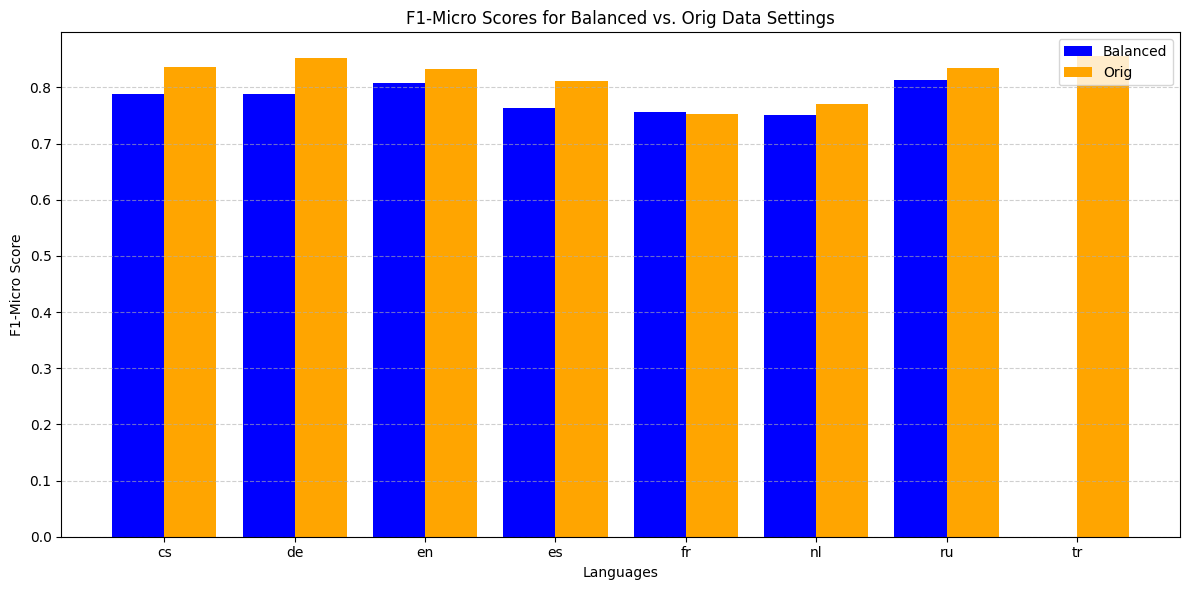

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

task = 'acd'
data_setting = 'orig'
lang_setting = 'adapted'
lr = '2e-05'

df_balanced = results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting,
                                   # results_all['learning_rate'] == lr
                                  ])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting,
                                            # results_all['learning_rate'] == lr
])].groupby("lang")["f1-micro"].idxmax()] 


task = 'acd'
data_setting = 'balanced'
lang_setting = 'orig'
lr = '2e-05'

df_orig = results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting,
                                   # results_all['learning_rate'] == lr
                                  ])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting,
                                            # results_all['learning_rate'] == lr
])].groupby("lang")["f1-micro"].idxmax()]  

# Merge the two dataframes on 'lang' (assuming language is the identifier)
df = pd.concat([df_balanced, df_orig])

# Filter to keep only 'balanced' and 'orig' settings
df = df[df["data_setting"].isin(["balanced", "orig"])]

# Extract languages and metrics (assuming 'f1-micro' is the metric you want to plot)
languages = df["lang"].unique()
x_indexes = np.arange(len(languages))
bar_width = 0.4  # Space for bars

# Extract F1-micro scores for both settings
f1_balanced = [
    df[(df["lang"] == lang) & (df["data_setting"] == "balanced")]["f1-micro"].values[0]
    if not df[(df["lang"] == lang) & (df["data_setting"] == "balanced")].empty else 0
    for lang in languages
]

f1_orig = [
    df[(df["lang"] == lang) & (df["data_setting"] == "orig")]["f1-micro"].values[0]
    if not df[(df["lang"] == lang) & (df["data_setting"] == "orig")].empty else 0
    for lang in languages
]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars
bars1 = ax.bar(x_indexes - bar_width / 2, f1_balanced, width=bar_width, color='blue', label="Balanced")
bars2 = ax.bar(x_indexes + bar_width / 2, f1_orig, width=bar_width, color='orange', label="Orig")

# Labels and formatting
ax.set_xticks(x_indexes)
ax.set_xticklabels(languages)
ax.set_xlabel("Languages")
ax.set_ylabel("F1-Micro Score")
ax.set_title("F1-Micro Scores for Balanced vs. Orig Data Settings")

# Add legend
ax.legend()

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()


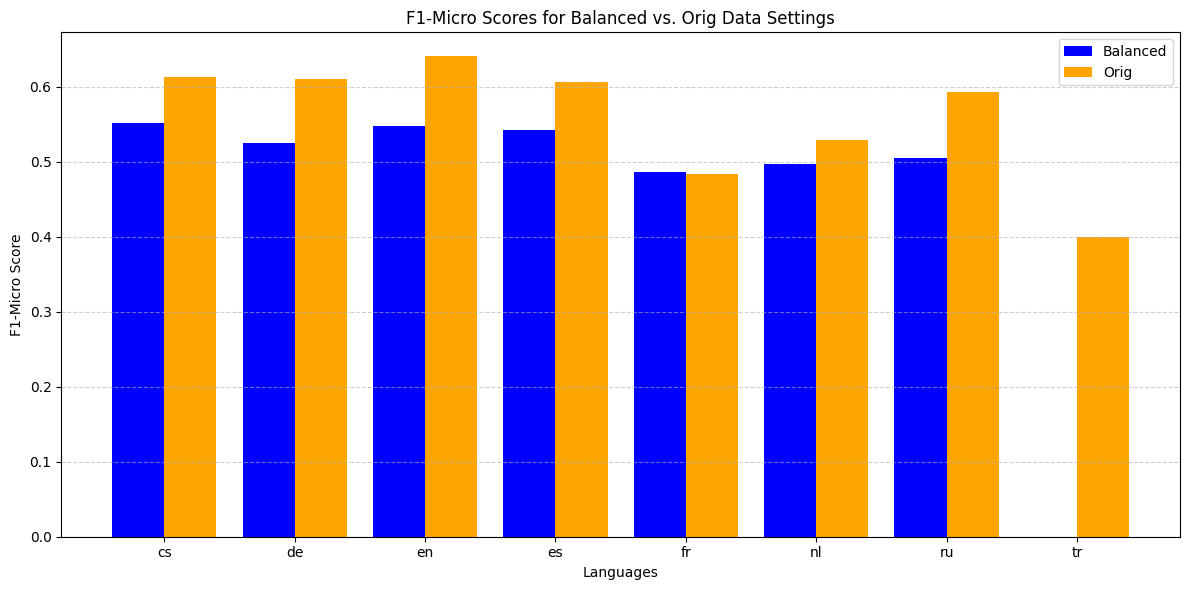

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

task = 'tasd'
data_setting = 'balanced'
lang_setting = 'orig'
lr = '2e-05'

df_balanced = results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting,
                                   # results_all['learning_rate'] == lr
                                  ])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting,
                                            # results_all['learning_rate'] == lr
])].groupby("lang")["f1-micro"].idxmax()] 


task = 'tasd'
data_setting = 'orig'
lang_setting = 'orig'
lr = '2e-05'

df_orig = results_all[np.logical_and.reduce([results_all['task'] == task, 
                                   results_all['data_setting'] == data_setting,
                                   results_all['lang_setting'] == lang_setting,
                                   # results_all['learning_rate'] == lr
                                  ])].loc[results_all[np.logical_and.reduce([
                                            results_all['task'] == task, 
                                            results_all['data_setting'] == data_setting,
                                            results_all['lang_setting'] == lang_setting,
                                            # results_all['learning_rate'] == lr
])].groupby("lang")["f1-micro"].idxmax()]  

# Merge the two dataframes on 'lang' (assuming language is the identifier)
df = pd.concat([df_balanced, df_orig])

# Filter to keep only 'balanced' and 'orig' settings
df = df[df["data_setting"].isin(["balanced", "orig"])]

# Extract languages and metrics (assuming 'f1-micro' is the metric you want to plot)
languages = df["lang"].unique()
x_indexes = np.arange(len(languages))
bar_width = 0.4  # Space for bars

# Extract F1-micro scores for both settings
f1_balanced = [
    df[(df["lang"] == lang) & (df["data_setting"] == "balanced")]["f1-micro"].values[0]
    if not df[(df["lang"] == lang) & (df["data_setting"] == "balanced")].empty else 0
    for lang in languages
]

f1_orig = [
    df[(df["lang"] == lang) & (df["data_setting"] == "orig")]["f1-micro"].values[0]
    if not df[(df["lang"] == lang) & (df["data_setting"] == "orig")].empty else 0
    for lang in languages
]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars
bars1 = ax.bar(x_indexes - bar_width / 2, f1_balanced, width=bar_width, color='blue', label="Balanced")
bars2 = ax.bar(x_indexes + bar_width / 2, f1_orig, width=bar_width, color='orange', label="Orig")

# Labels and formatting
ax.set_xticks(x_indexes)
ax.set_xticklabels(languages)
ax.set_xlabel("Languages")
ax.set_ylabel("F1-Micro Score")
ax.set_title("F1-Micro Scores for Balanced vs. Orig Data Settings")

# Add legend
ax.legend()

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()
